# **Instructions:**
Start by selecting `File` and then `Save a copy in Drive`. Rename that copy so that **your initials** are included in the name of the file somewhere.

***

# **Time-Series Data: Looking at river gage data with the USGS**
Here we will demonstrate how to use data from the **United States Geological Survey (USGS)** to look at how river gage discharge and height change over time using Google Colab. For this demonstration we will use data from a USGS gage located on the **Cheyenne River** near Wasta, South Dakota. This area experienced extensive flooding in 2019. Our goal is to see if we can detect that flooding event in the data and determine just how out-of-the-ordinary this event really was.

![https://github.com/cu-esiil-edu/stars-2026/blob/main/img/Screen%20Shot%202026-05-28%20at%204.42.58%20PM.png?raw=true](https://github.com/cu-esiil-edu/stars-2026/blob/main/img/Screen%20Shot%202026-05-28%20at%204.42.58%20PM.png?raw=true)

You can read more about this particular USGS river gage here:
[https://waterdata.usgs.gov/monitoring-location/USGS-06423500/#period=P7D&dataTypeId=continuous-00060-0&showMedian=true&showFieldMeasurements=true](https://waterdata.usgs.gov/monitoring-location/USGS-06423500/#period=P7D&dataTypeId=continuous-00060-0&showMedian=true&showFieldMeasurements=true)

**By the end of this notebook you will be able to:**
* Retrieve data from the USGS for a specified river gaging station
* Work with time series data:
  * Wrangle
  * Visualize
  * Subset
  * Resample
* Apply the workflow to another gaging station that you are interested in

Note that while rivers and flooding are the context for this particular notebook, the skills you will learn here (eg. wrangling, vizualizing, subsetting, resampling) will be applicable to any time-series data that you may encounter in your research and teaching.

***

This notebook uses a few Python libraries that are not automatically included in Google Colab. We will install them first so we can retrieve USGS river data, make maps, and create interactive plots.

In [41]:
# Install libraries that aren't native to Colab
!pip install osmnx hvplot geoviews dataretrieval

## **Import Python libraries**

Now that the required libraries are installed, we need to import them into the notebook. Importing a library makes its tools available for us to use in our code.

In this notebook, we will use Python libraries to:

- retrieve streamflow and gage-height data from the USGS
- store and clean the data in tables
- make static and interactive plots
- create a map showing the location of the river gage

You do not need to memorize what each library does right now. As we use them, you will see how each one helps us work with real environmental data.

In [42]:
# Import python libraries

import dataretrieval # to retrieve data from USGS

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

import hvplot.pandas  # enables .hvplot on GeoDataFrames
import holoviews as hv
from holoviews import opts
from holoviews.element.tiles import EsriImagery
import geoviews
hv.extension('bokeh')

## **Define the river gage and date range**

Next, we will define the USGS river gage that we want to investigate. A **river gage** is a monitoring station that collects measurements about river conditions through time.

For this notebook, we will use data from USGS gage `06423500`, located on the Cheyenne River near Wasta, South Dakota. This location gives us a real environmental dataset from a place that may be familiar to some students.

We will also define the time period for our data request. The start and end dates tell Python which years of data to retrieve from the USGS.

The parameter codes tell the USGS which variables we want:

- `00060` = streamflow, also called discharge
- `00065` = gage height, or the height of the water surface at the gage

These two measurements will help us investigate how the river changed before, during, and after the 2019 flood.

In [43]:
# Define site parameters here
gage_number = '06423500'
gage_lat = 44.0810984869115
gage_lon = -102.401274556676
start_date = '1934-10-01'
end_date = '2024-09-30'
parameter_codes = ['00060','00065'] # Streamflow , gage height

Notice that the latitude and longitude values are not in quotes. This is because they are numbers that Python can use for mapping and calculations. Values in quotes are treated as text, while values without quotes can be treated as numbers.

## **Create a spatial point for the river gage**

The USGS river gage has a latitude and longitude, which tell us where it is located on Earth. To map the gage, we need to turn those coordinates into a spatial data object.

This cell creates a **GeoDataFrame**, which is similar to a regular data table, but it also includes a geometry column that stores location information. In this case, the geometry is a single point representing the river gage.

The coordinate reference system, or **CRS**, is set to `EPSG:4326`, which is commonly used for latitude and longitude coordinates.

In [44]:
# Create a GeoDataFrame with the gage location
gage_gdf = gpd.GeoDataFrame(
    # Create the geometry from lat/lon
    geometry=gpd.points_from_xy([gage_lon], [gage_lat]),
    # Coordinate Reference System for lat/lon values
    crs="EPSG:4326"
)

gage_gdf

,geometry
0,POINT (-102.40127 44.0811)


## **Map the river gage location**

Before we begin analyzing the river data, it is helpful to see where the gage is located. Data are connected to real places, and mapping the gage helps us better understand the landscape where the measurements were collected.

This cell creates an interactive map with aerial imagery as the basemap. The blue point marks the location of the USGS river gage. You can zoom in, zoom out, and pan around the map to explore the surrounding area.

**Think about it:** What do you notice about the land, roads, or river channel near this gage?

In [45]:
# Plot using hvPlot with a basemap
buffer = 0.01
gage_gdf.hvplot.points(
    # Use web tile basemap imagery
    geo=True, tiles='EsriImagery',
    # Format streamgage marker
    color='blue', size=100,
    # Set figure size
    width=500, height=300,
    # Set approximate bounding box
    ylim=(gage_lat-buffer, gage_lat+buffer),
    xlim=(gage_lon-buffer, gage_lon+buffer),
    # Remove axis labels
    xaxis=None, yaxis=None)


:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]

## **Retrieve daily river data from the USGS**

Now we are ready to request real river data from the USGS National Water Information System, or **NWIS**. Instead of using a spreadsheet that has already been downloaded, this code connects directly to the USGS data service and retrieves data for the gage, variables, and date range we defined earlier.

This cell returns two objects:

- `nwis_df`: a data table containing daily river measurements
- `meta`: metadata, or information about the data request and monitoring site

The function `get_dv()` requests **daily values**. In this notebook, we are requesting daily streamflow and daily gage height so we can investigate long-term river patterns and the 2019 flood event.

### **A note about retrieving live data**

This notebook retrieves data directly from the USGS instead of using a static file. This is powerful because we can access real, current environmental data, but it also means the code depends on an online data service.

If the data request does not work, it does not always mean your code is wrong. Possible issues include a temporary internet problem, a temporary USGS service issue, a package-version change, missing data for a specific site or variable, or a very large request that takes too long to complete.

When working with live environmental data, it is good practice to check the site number, parameter codes, date range, and returned DataFrame before continuing.

In [46]:
# Get discharge data and metadata from NWIS
nwis_df, meta = dataretrieval.nwis.get_dv(
    sites=gage_number,
    parameterCd=parameter_codes,
    startDt=start_date,
    endDt=end_date)
nwis_df

/tmp/ipykernel_33617/1846646919.py:2: DeprecationWarning: `nwis.get_dv` is deprecated and will be removed from `dataretrieval` on or after 2027-05-06; use `waterdata.get_daily()` instead.
  nwis_df, meta = dataretrieval.nwis.get_dv(


,00060_Mean,00060_Mean_cd,00065_Mean,00065_Mean_cd,site_no
datetime,,,,,
1934-10-01 00:00:00+00:00,54.0,A,NaN,NaN,06423500
1934-10-02 00:00:00+00:00,51.0,A,NaN,NaN,06423500
1934-10-03 00:00:00+00:00,51.0,A,NaN,NaN,06423500
1934-10-04 00:00:00+00:00,54.0,A,NaN,NaN,06423500
1934-10-05 00:00:00+00:00,54.0,A,NaN,NaN,06423500
...,...,...,...,...,...
2024-09-26 00:00:00+00:00,103.0,A,0.44,A,06423500
2024-09-27 00:00:00+00:00,94.9,A,0.40,A,06423500
2024-09-28 00:00:00+00:00,90.7,A,0.39,A,06423500


## **Clean up the data table**

The data returned by the USGS includes column names based on USGS parameter codes. These codes are useful for the database, but they can be difficult to read when we are learning or making plots.

This cell keeps only the two columns we need for our flood investigation:

- streamflow, measured in cubic feet per second
- gage height, measured in feet

It also renames the columns so they are easier to understand. Clear column names make the data easier to work with and help reduce mistakes later in the notebook.

In [47]:
nwis_df = (
    nwis_df
    # Select only the discharge and gage height columns as a DataFrame
    [['00060_Mean','00065_Mean']]
    # Rename the discharge column
    .rename(columns={'00060_Mean': 'streamflow_cfs',
                     '00065_Mean': 'height_ft'})
)

nwis_df

,streamflow_cfs,height_ft
datetime,,
1934-10-01 00:00:00+00:00,54.0,NaN
1934-10-02 00:00:00+00:00,51.0,NaN
1934-10-03 00:00:00+00:00,51.0,NaN
1934-10-04 00:00:00+00:00,54.0,NaN
1934-10-05 00:00:00+00:00,54.0,NaN
...,...,...
2024-09-26 00:00:00+00:00,103.0,0.44
2024-09-27 00:00:00+00:00,94.9,0.40
2024-09-28 00:00:00+00:00,90.7,0.39


## **Visualize river conditions through time**

Now that the data are cleaned, we can create time-series plots. A **time series** shows how a variable changes through time. In this case, each point along the x-axis represents a date, and the y-axis shows a river measurement from the USGS gage.

We will first plot:

- **streamflow**, which tells us how much water is moving through the river
- **gage height**, which tells us how high the water surface is at the gage

Interactive plots are useful because you can zoom in, pan across time, and hover over the graph to inspect individual values.

**Think about it:** What patterns do you notice over the full record? Are there years when the river appears much higher than usual?

In [48]:
# Create an interactive plot of streamflow
nwis_df.hvplot(y='streamflow_cfs',
               title='Streamflow at Cheyenne River, Wasta, SD',
               ylabel='Streamflow (cfs)',
               xlabel='Date')

:Curve   [datetime]   (streamflow_cfs)

In [49]:
# Create an interactive plot of gage height
nwis_df.hvplot(y='height_ft',
               title='Gage Height at Cheyenne River, Wasta, SD',
               ylabel='Gage Height (ft)',
               xlabel='Date')

:Curve   [datetime]   (height_ft)

## **Bonus plot using Matplotlib**

The previous plots used `hvplot`, which creates interactive visualizations. This bonus cell shows how to make a similar time-series plot using `matplotlib`, one of the most common plotting libraries in Python.

This plot is not interactive, but it gives you more direct control over common figure settings such as:

- figure size
- plot title
- x- and y-axis labels
- rotated date labels
- grid lines

Learning both interactive and static plotting approaches is useful. Interactive plots are helpful for exploring data, while static plots are often useful for reports, slides, and publications.

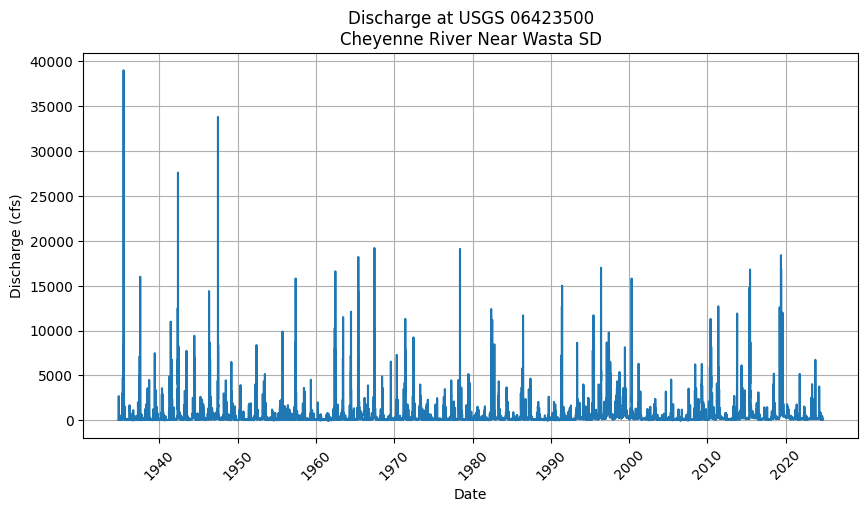

In [50]:
# -----------------------------
# BONUS: Plot discharge (using matplotlib)
# -----------------------------

plt.figure(figsize=(10, 5))

plt.plot(nwis_df["streamflow_cfs"])

plt.title(
    "Discharge at USGS 06423500\nCheyenne River Near Wasta SD"
)
plt.xlabel("Date")
plt.ylabel("Discharge (cfs)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## **Focus on the 2019 flood year**

The full dataset includes almost 100 years of river measurements. To investigate the 2019 flood more closely, we need to create a smaller dataset that only includes values from 2019.

Because the DataFrame index contains dates, we can use a date range to subset the data. This cell keeps only the rows from January 2019 through December 2019 and stores them in a new DataFrame called `df_2019_flood`.

This makes it easier to zoom in on what happened before, during, and after the flood event.

In [51]:
# Subset the data to look at 2019
df_2019_flood = nwis_df.loc["2019"]

df_2019_flood

,streamflow_cfs,height_ft
datetime,,
2019-01-01 00:00:00+00:00,235.0,NaN
2019-01-02 00:00:00+00:00,259.0,NaN
2019-01-03 00:00:00+00:00,261.0,NaN
2019-01-04 00:00:00+00:00,264.0,NaN
2019-01-05 00:00:00+00:00,267.0,NaN
...,...,...
2019-12-27 00:00:00+00:00,400.0,1.29
2019-12-28 00:00:00+00:00,415.0,1.32
2019-12-29 00:00:00+00:00,379.0,NaN


## **Plot streamflow during the 2019 flood year**

Now that we have created a smaller dataset for 2019, we can plot streamflow during that year. This helps us look more closely at whether the flood appears in the river gage record.

In a streamflow time series, a flood may show up as a sharp increase, or **peak**, where much more water than usual was moving through the river.

As you look at the plot, consider:

- When does streamflow begin to rise?
- When does streamflow reach its highest value?
- Does streamflow drop quickly or slowly after the peak?
- Are there multiple high-flow events during the year?

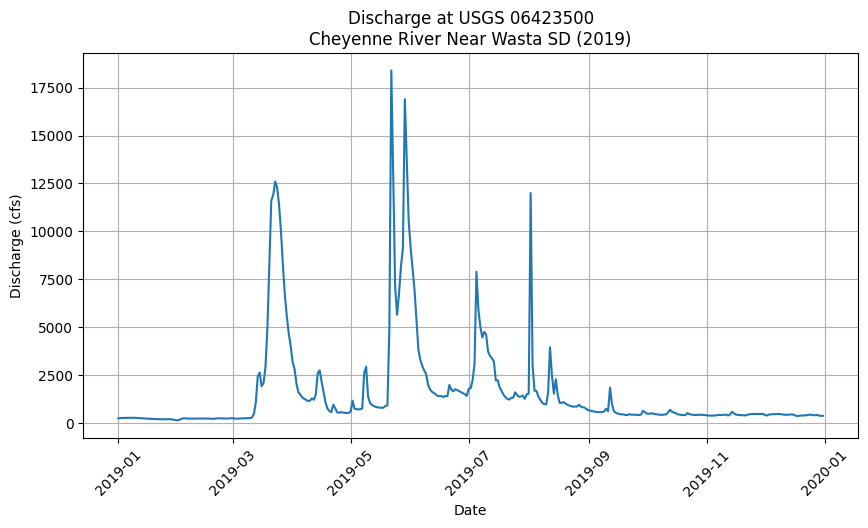

In [52]:
# Plot the 2019 data to see if flooding can be detected
plt.figure(figsize=(10, 5))

plt.plot(df_2019_flood["streamflow_cfs"])

plt.title(
    "Discharge at USGS 06423500\nCheyenne River Near Wasta SD (2019)"
)
plt.xlabel("Date")
plt.ylabel("Discharge (cfs)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## **Calculate monthly averages**

Daily data can show short-term changes, such as sharp flood peaks. Sometimes, however, it is helpful to summarize the data over a longer time period so we can see broader patterns.

This cell uses **resampling** to convert the daily 2019 data into monthly averages. The code groups the data by month and calculates the mean streamflow and mean gage height for each month.

The `'ME'` part means **month end**, so each monthly average is labeled using the last day of that month.

Monthly averages can help us answer questions such as:

- Which months had the highest average streamflow?
- How does the flood month compare with the rest of the year?
- What details are easier to see in daily data than in monthly averages?

In [53]:
# Resample
df_2019_monthly_mean = df_2019_flood.resample('ME').mean()
df_2019_monthly_mean

,streamflow_cfs,height_ft
datetime,,
2019-01-31 00:00:00+00:00,222.516129,NaN
2019-02-28 00:00:00+00:00,225.035714,NaN
2019-03-31 00:00:00+00:00,4144.806452,7.367273
2019-04-30 00:00:00+00:00,1294.900000,2.354483
2019-05-31 00:00:00+00:00,4359.612903,4.240968
2019-06-30 00:00:00+00:00,2608.000000,3.497000
2019-07-31 00:00:00+00:00,2620.000000,3.541290
2019-08-31 00:00:00+00:00,1685.935484,2.643548
2019-09-30 00:00:00+00:00,585.400000,1.523333


## **Plot monthly average streamflow**

Now we can plot the monthly average streamflow values for 2019. This plot shows the same river system as the daily plot, but the data have been summarized by month.

Monthly averages can make broad seasonal patterns easier to see, but they can also smooth over short-term flood peaks. This is an important part of working with time-series data: the time scale you choose can change what patterns are most visible.

**Think about it:** How does the monthly average plot compare with the daily streamflow plot? Does the flood look more obvious or less obvious after resampling?

In [54]:
# Plot the 2019 monthly mean discharge
df_2019_monthly_mean.hvplot(
    y='streamflow_cfs',
    xlabel='Date',
    ylabel='Monthly average streamflow (cfs)',
    title='Monthly Average Streamflow at Cheyenne River Near Wasta SD (2019)'
)

:Curve   [datetime]   (streamflow_cfs)

## **How rare was the 2019 flood?**

So far, we have zoomed in on the 2019 data to look for evidence of flooding. Now we will zoom back out and compare 2019 to the full river record.

This helps us ask a bigger question:

**Was the 2019 flood common, unusual, or extreme for this river?**

To investigate this, we will compare the largest streamflow value from 2019 with the largest streamflow values from other years. If the 2019 peak is one of the highest values in the record, that tells us the event was unusual compared with this river’s history.

We will also introduce the idea of a **return period**, which is a way to describe how rare a flood event is. A larger return period means a flood is less common. However, return periods are estimates based on past data, not exact schedules for when floods will happen.

## **View the full streamflow record**

Before we estimate how unusual the 2019 flood was, we should look at the full streamflow record. This gives us the “big picture” of how the Cheyenne River has changed over time.

The plot below shows about 90 years of streamflow data. By looking across the full record, we can compare the 2019 flood with other high-flow events and begin to ask whether 2019 was common, unusual, or extreme for this river.

**Think about it:** Where do you see the largest streamflow peaks in the record? Does 2019 appear to stand out compared with other years?

<Axes: title={'center': '90 Years of Streamflow on the Cheyenne River'}, xlabel='Date', ylabel='Streamflow (cfs)'>

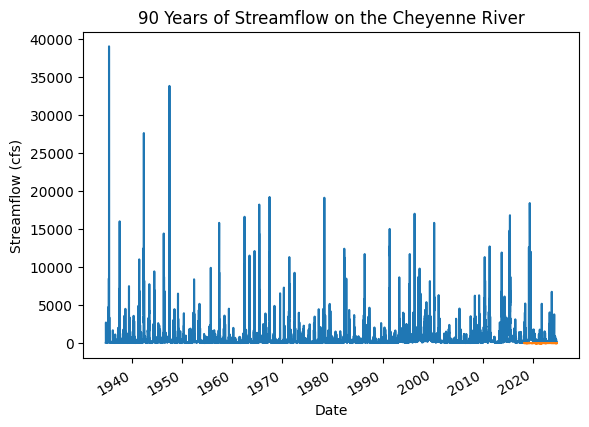

In [55]:
# Plot the entire streamflow time series
nwis_df.plot(
        xlabel='Date',
        ylabel='Streamflow (cfs)',
        title='90 Years of Streamflow on the Cheyenne River',
        legend=False)

## **Calculate annual maximum streamflow**

Flood-frequency analysis usually focuses on the largest streamflow value from each year. This value is called the **annual maximum streamflow**.

To calculate it, we will resample the daily data by year and keep the maximum streamflow value for each year. This gives us one peak-flow value per year, making it easier to compare the 2019 flood with other large events in the long-term record.

In [56]:
# Resample to annual maxima
peaks_df = nwis_df.resample('YS').max()
peaks_df

,streamflow_cfs,height_ft
datetime,,
1934-01-01 00:00:00+00:00,2700.0,NaN
1935-01-01 00:00:00+00:00,39000.0,NaN
1936-01-01 00:00:00+00:00,1680.0,NaN
1937-01-01 00:00:00+00:00,16000.0,NaN
1938-01-01 00:00:00+00:00,4500.0,NaN
...,...,...
2020-01-01 00:00:00+00:00,1800.0,3.01
2021-01-01 00:00:00+00:00,5170.0,5.05
2022-01-01 00:00:00+00:00,1540.0,2.23


<Axes: xlabel='datetime'>

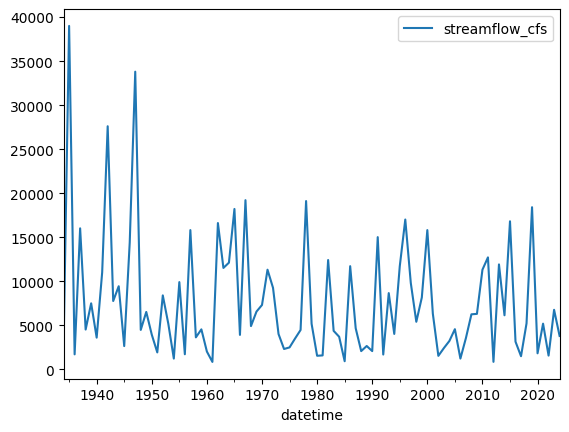

In [57]:
# Plot annual maximum discharge
peaks_df.plot(y='streamflow_cfs')

## **Account for changes in river management**

Before estimating flood frequency, we need to think carefully about whether the full streamflow record represents the same river conditions through time.

This river has not always flowed under the same conditions. In 1948, a dam was constructed on the Cheyenne River, which affected the river’s hydrology. Dams can change river flow by storing, releasing, slowing, or regulating water. Because of this, streamflow values before and after dam construction may not be directly comparable.

To make our flood analysis more consistent, we will focus only on the part of the record after the dam was built. This helps us compare the 2019 flood with other years that occurred under a more similar flow regime.

In the next step, we will subset the data so that our flood-frequency analysis only includes post-dam streamflow values.

In [58]:
# Subsetting to focus on values after dam construction (1948)
peaks_df = peaks_df.loc['1948':]
peaks_df

,streamflow_cfs,height_ft
datetime,,
1948-01-01 00:00:00+00:00,4460.0,NaN
1949-01-01 00:00:00+00:00,6500.0,NaN
1950-01-01 00:00:00+00:00,3920.0,NaN
1951-01-01 00:00:00+00:00,1900.0,NaN
1952-01-01 00:00:00+00:00,8380.0,NaN
...,...,...
2020-01-01 00:00:00+00:00,1800.0,3.01
2021-01-01 00:00:00+00:00,5170.0,5.05
2022-01-01 00:00:00+00:00,1540.0,2.23


## **Estimate exceedance probability and return period**

Now that we have one peak streamflow value for each year, we can estimate how unusual each annual peak was compared with the rest of the record.

To do this, we will calculate two related values:

- **Exceedance probability**: the chance that a streamflow value of this size or larger will be equaled or exceeded in a given year
- **Return period**: the average number of years between events of this size or larger

The code below ranks the annual peak streamflow values from largest to smallest. The largest flood receives the highest rank, meaning it has the lowest exceedance probability and the longest return period.

Return period is calculated as:

`return period = 1 / exceedance probability`

For example, if a flood has an exceedance probability of `0.10`, then its estimated return period is `10` years. This does **not** mean the flood happens exactly every 10 years. It means that, based on this record, a flood of that size or larger has about a 10% chance of occurring in any given year.

**Think about it:** Find the 2019 peak in the table. What is its estimated return period, and what does that suggest about how unusual the flood was compared with other years in the record?

In [59]:
# Make a copy so this is a dataframe and not a view
peaks_df = peaks_df.copy()

# Calculate exceedance probability
peaks_df['exceed_prob'] = (
    peaks_df.rank(ascending=False).streamflow_cfs
    / len(peaks_df)
)
# Calculate return period
peaks_df['return_period'] = 1 / peaks_df.exceed_prob

peaks_df

,streamflow_cfs,height_ft,exceed_prob,return_period
datetime,,,,
1948-01-01 00:00:00+00:00,4460.0,NaN,0.558442,1.790698
1949-01-01 00:00:00+00:00,6500.0,NaN,0.376623,2.655172
1950-01-01 00:00:00+00:00,3920.0,NaN,0.623377,1.604167
1951-01-01 00:00:00+00:00,1900.0,NaN,0.831169,1.203125
1952-01-01 00:00:00+00:00,8380.0,NaN,0.311688,3.208333
...,...,...,...,...
2020-01-01 00:00:00+00:00,1800.0,3.01,0.844156,1.184615
2021-01-01 00:00:00+00:00,5170.0,5.05,0.467532,2.138889
2022-01-01 00:00:00+00:00,1540.0,2.23,0.896104,1.115942


In [60]:
# Find 2019 and evaluate
peaks_df.loc['2019']

,streamflow_cfs,height_ft,exceed_prob,return_period
datetime,,,,
2019-01-01 00:00:00+00:00,18400.0,11.6,0.038961,25.666667


## **Interpret the 2019 flood frequency results**

The table above shows the annual peak streamflow value for 2019 and its estimated return period.

For 2019, the annual maximum streamflow was **18,400 cubic feet per second (cfs)**, with a gage height of **11.6 feet**. Based on the annual peak streamflow record used in this analysis, this event had an estimated **exceedance probability of about 0.039**, or **3.9%**.

The return period is calculated as:

`1 / exceedance probability`

For this event:

`1 / 0.038961 ≈ 25.7 years`

This means the 2019 flood was approximately a **26-year flood** at this gage, based on the data included in this analysis.

A 26-year flood does **not** mean that this type of flood happens exactly every 26 years. Instead, it means that a flood of this size or larger has about a **3.9% chance of occurring in any given year**, based on the historical record.

## **Visualize flood events in different ways**

There is not just one “correct” way to visualize a flood event. Different plots help us answer different questions.

A **time-series plot** helps us see when streamflow rose, when the flood peaked, and how quickly the river returned to lower flows.

A **bar plot of annual peak streamflow** helps us compare the largest flow from each year and see whether one year stands out from the historical record.

A **flood-frequency plot** helps us connect streamflow to return period. This lets us see how unusual a flood was compared with other annual peak flows.

In the next few cells, we will try a few different visualizations. As you look at each plot, think about what the plot makes easier to see and what information might be harder to interpret.


## **Compare yearly flood peaks**

Each bar shows the largest streamflow value recorded during one year. The 2019 flood is highlighted in orange so we can compare it with other annual peak flows in the record.

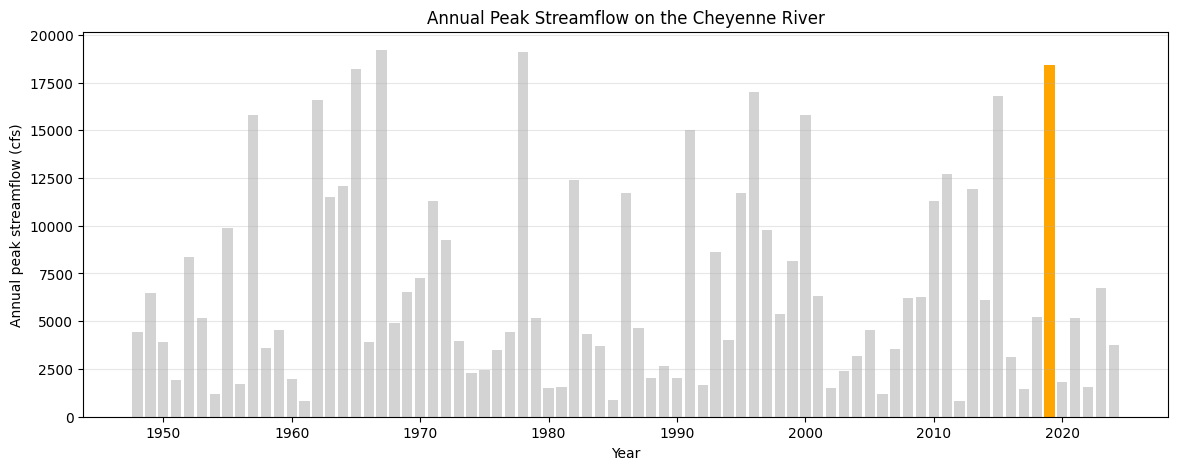

In [61]:
# Create a copy for plotting
plot_df = peaks_df.copy()

# Create a year column from the datetime index
plot_df["year"] = plot_df.index.year

# Create colors: highlight 2019
colors = [
    "orange" if year == 2019 else "lightgray"
    for year in plot_df["year"]
]

# Plot annual peak streamflow
plt.figure(figsize=(14, 5))

plt.bar(
    plot_df["year"],
    plot_df["streamflow_cfs"],
    color=colors
)

plt.title("Annual Peak Streamflow on the Cheyenne River")
plt.xlabel("Year")
plt.ylabel("Annual peak streamflow (cfs)")
plt.grid(axis="y", alpha=0.3)

plt.show()

## Visualize the 2019 return period

Each point shows one year’s maximum streamflow compared with its estimated return period. The 2019 flood is highlighted in orange so we can see where it falls in the flood-frequency record.

Because the 2019 point is near a return period of 26 years, this suggests that a flood of this size or larger has about a 1 in 26 chance of occurring in any given year.

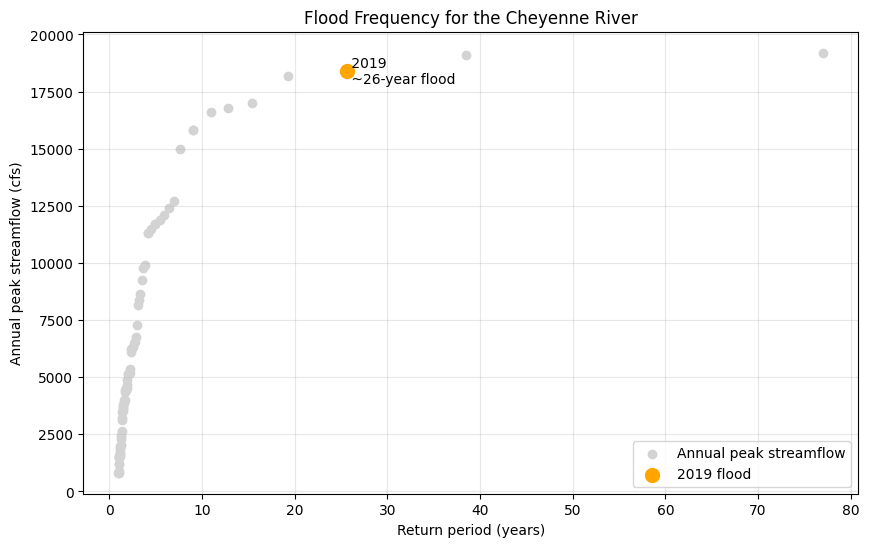

In [62]:
# Create a copy for plotting
plot_df = peaks_df.copy()

# Create a year column
plot_df["year"] = plot_df.index.year

# Separate the 2019 flood
flood_2019 = plot_df[plot_df["year"] == 2019]

# Plot return period vs streamflow
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df["return_period"],
    plot_df["streamflow_cfs"],
    color="lightgray",
    label="Annual peak streamflow"
)

# Highlight 2019
plt.scatter(
    flood_2019["return_period"],
    flood_2019["streamflow_cfs"],
    color="orange",
    s=100,
    label="2019 flood"
)

# Add a label for the 2019 point
plt.text(
    flood_2019["return_period"].iloc[0],
    flood_2019["streamflow_cfs"].iloc[0],
    " 2019\n ~26-year flood",
    verticalalignment="center"
)

plt.title("Flood Frequency for the Cheyenne River")
plt.xlabel("Return period (years)")
plt.ylabel("Annual peak streamflow (cfs)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## Explore flood frequency interactively

This plot shows the same flood-frequency relationship as the previous scatter plot, but now it is interactive. Each point represents the largest streamflow value from one year.

Instead of labeling every year on the plot, which can make the graph crowded, we can use hover information. Move your cursor over a point to see the year, annual peak streamflow, and estimated return period.

This makes it easier to explore the full dataset while keeping the visualization clean.

**Try it:** Hover over the 2019 point. Then compare it with points that have shorter and longer return periods. What do you notice about how streamflow changes as return period increases?

In [63]:
# Create a year column for hover information
plot_df = peaks_df.copy()
plot_df["year"] = plot_df.index.year

plot_df.hvplot.scatter(
    x="return_period",
    y="streamflow_cfs",
    hover_cols=["year", "streamflow_cfs", "return_period"],
    xlabel="Return period (years)",
    ylabel="Annual peak streamflow (cfs)",
    title="Flood Frequency for the Cheyenne River",
    width=700,
    height=450
)

:Scatter   [return_period]   (streamflow_cfs,year)

## **Try it yourself**

Choose a USGS river gage or flood event that interests you and try to recreate the workflow from this notebook.

Update the gage number, location, date range, and parameter codes. Then retrieve the data, clean the table, plot the streamflow time series, zoom in on a flood event, and estimate how unusual the event was compared with the long-term record. You can do this by adding new code cells to this notebook, or creating a new notebook from scratch - whatever is easier for you!

### **Challenge options**

- Make a bar plot of annual maximum streamflow.
- Change the plot colors, labels, or title.
- Compare streamflow and gage height.
- Calculate annual mean, monthly mean, minimum, or median streamflow.
- Look for seasonal patterns in high-flow events.
- Compare two gages from the same region.
- Write a short summary of your flood event and its estimated return period.

**Reflection:** What did your analysis show about the flood event you selected?